In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Import our custom utilities
from utils.plotting import plot_emg_channels, plot_emg_channel, plot_motion_channels, plot_tactile_channels, plot_overlapping_modalities, plot_cross_modal_timeline

# Comprehensive Analysis of Subject 1 - ReachGrasp Dataset

This notebook provides a comprehensive analysis of all data modalities for Subject 1 in the ReachGrasp dataset. We'll explore:

1. **Electromyography (EMG)**: Muscle activation patterns
2. **Motion Capture**: Joint kinematics and movement trajectories  
3. **Tactile Sensing**: Force measurements from the hand
4. **Cross-modal Analysis**: Relationships between different data types

## Data Overview

Subject 1 has multimodal recordings for 16 different hand movement tasks:
- **EMG**: 2 acquisition systems (Cometa: 10 channels, Sessantaquattro: 64 channels) at 2000 Hz
- **Motion**: 2 acquisition systems (CyberGlove, Vicon) with joint angles at 100 Hz
- **Tactile**: 1 acquisition system (TactileGlove) with force sensors at 100 Hz

## Comparison of EMG Acquisition Systems

Let's compare the EMG data from the two acquisition systems for the same task (Cylindrical grasp).

In [2]:
# Load EMG data from Cometa acquisition system for Cylindrical grasp task
path = os.path.join(os.getcwd(), 'sub-01', 'emg', 'sub-01_task-Cyl_acq-cometa_emg.csv')
data = pd.read_csv(path, header=None)
time = data.iloc[:, 0]
emg_channels = data.iloc[:, 1:]

print(f"Cometa data shape: {data.shape}")
print(f"Time range: {time.min():.3f} to {time.max():.3f} seconds")
print(f"EMG channels: {emg_channels.shape[1]}")
print(f"Sampling frequency: 2000 Hz")
print(f"Recording duration: {time.max():.2f} seconds")

Cometa data shape: (118701, 11)
Time range: 0.000 to 59.350 seconds
EMG channels: 10
Sampling frequency: 2000 Hz
Recording duration: 59.35 seconds


In [3]:
# Load EMG data from the other acquisition system (Sessantaquattro)
path_sess = os.path.join(os.getcwd(), 'sub-01', 'emg', 'sub-01_task-Cyl_acq-sessantaquattro_emg.csv')
data_sess = pd.read_csv(path_sess, header=None)
time_sess = data_sess.iloc[:, 0]
emg_channels_sess = data_sess.iloc[:, 1:]

print(f"Sessantaquattro data shape: {data_sess.shape}")
print(f"Time range: {time_sess.min():.3f} to {time_sess.max():.3f} seconds")
print(f"EMG channels: {emg_channels_sess.shape[1]}")

Sessantaquattro data shape: (118701, 65)
Time range: 0.000 to 59.350 seconds
EMG channels: 64


EMG Channels - Cometa System (10 channels, Cylindrical Grasp):


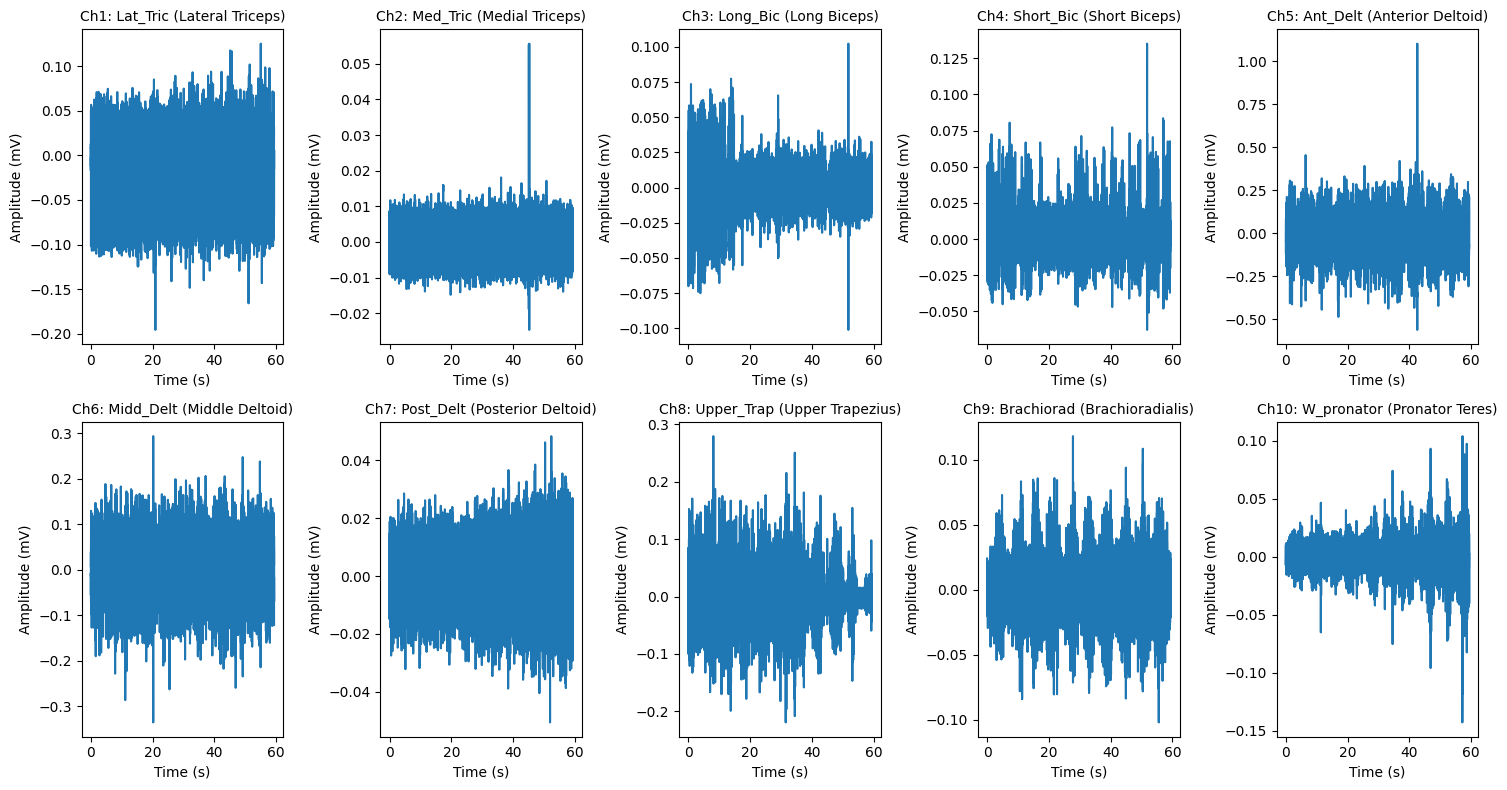


EMG Channels - Sessantaquattro System (64 channels total, first 32 shown):


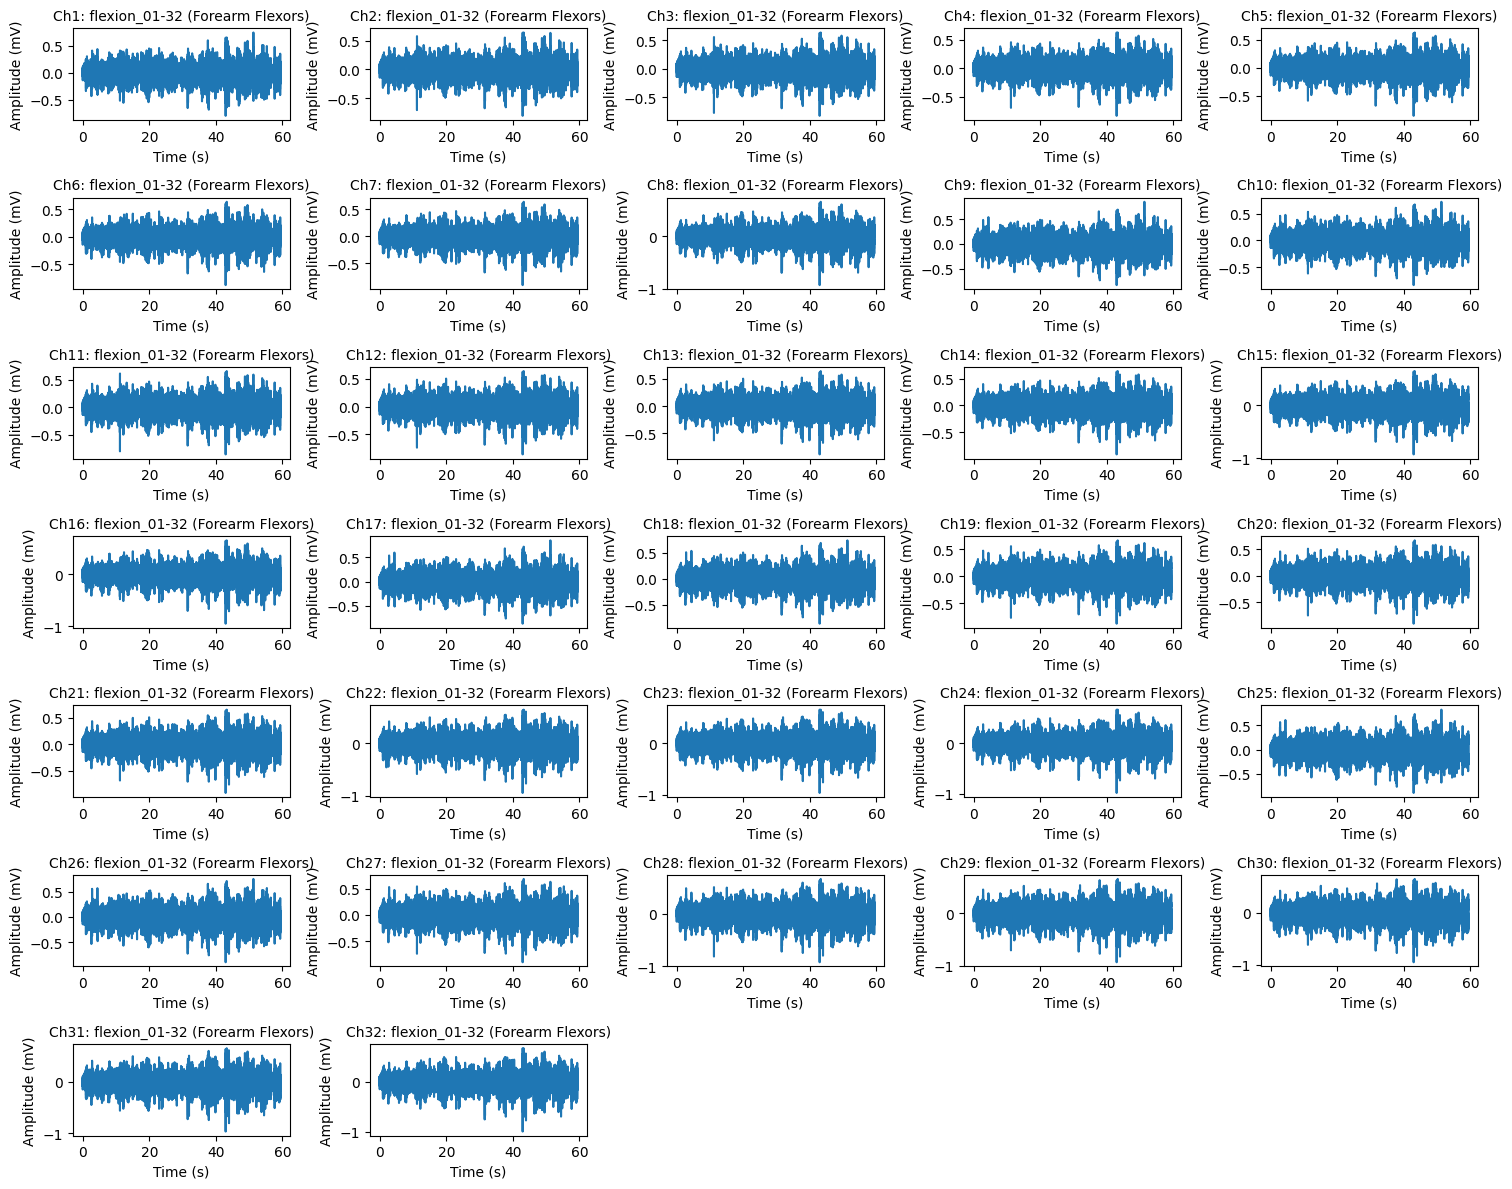

Cometa system: 10 channels
Sessantaquattro system: 64 channels


In [4]:
# Compare the two acquisition systems for the same task
# Compare EMG systems using utility functions
print("EMG Channels - Cometa System (10 channels, Cylindrical Grasp):")
plot_emg_channels(time, emg_channels, show_labels=True, acquisition='cometa', figsize=(15, 8))

print("\nEMG Channels - Sessantaquattro System (64 channels total, first 32 shown):")
# For Sessantaquattro, show first 32 channels (flexion group)
plot_emg_channels(time_sess, emg_channels_sess.iloc[:, :32], show_labels=True, acquisition='sessantaquattro', figsize=(15, 12))

print(f"Cometa system: {emg_channels.shape[1]} channels")
print(f"Sessantaquattro system: {emg_channels_sess.shape[1]} channels")

EMG Channels Overlapping (All Muscle Channels on Same Plot - Cometa System):


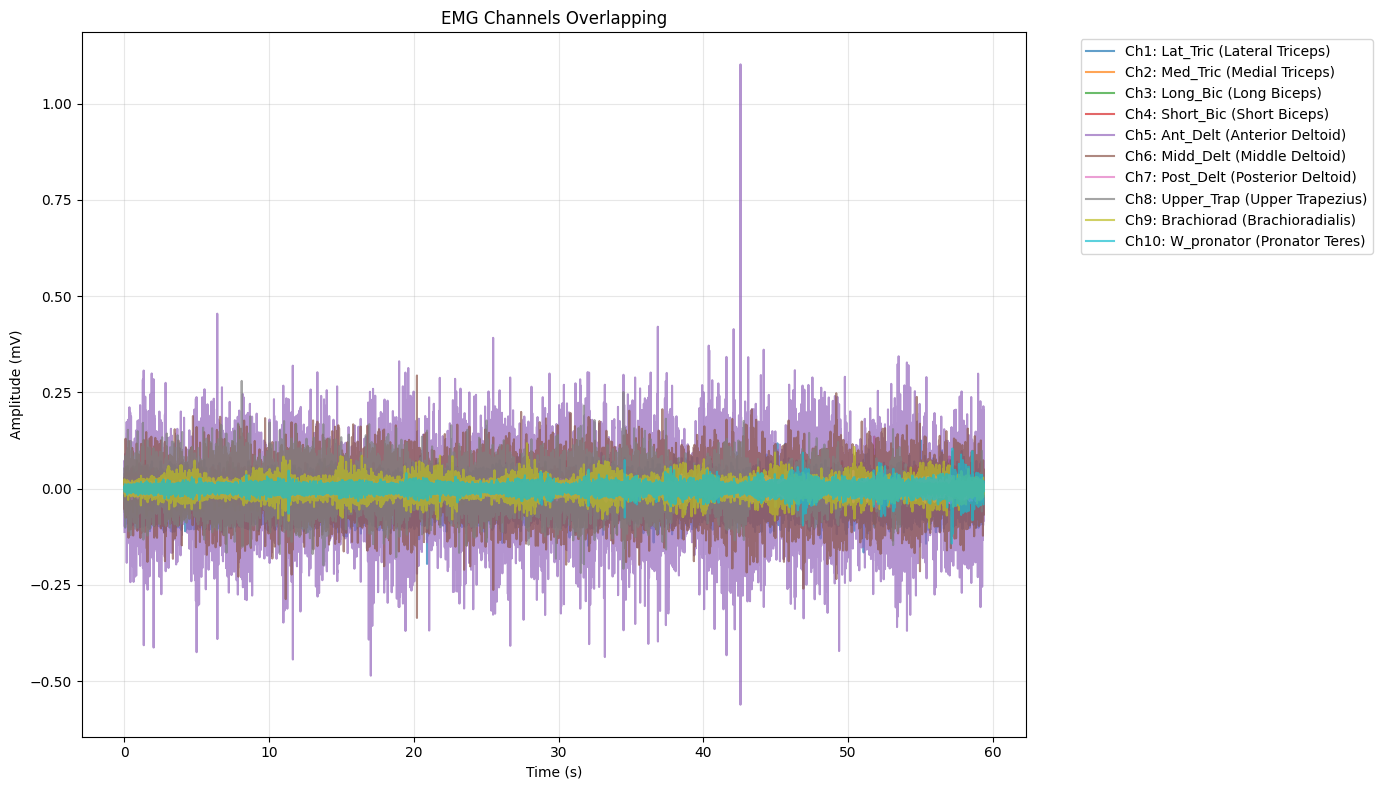


EMG Channels Overlapping (First 10 Channels - Sessantaquattro System):


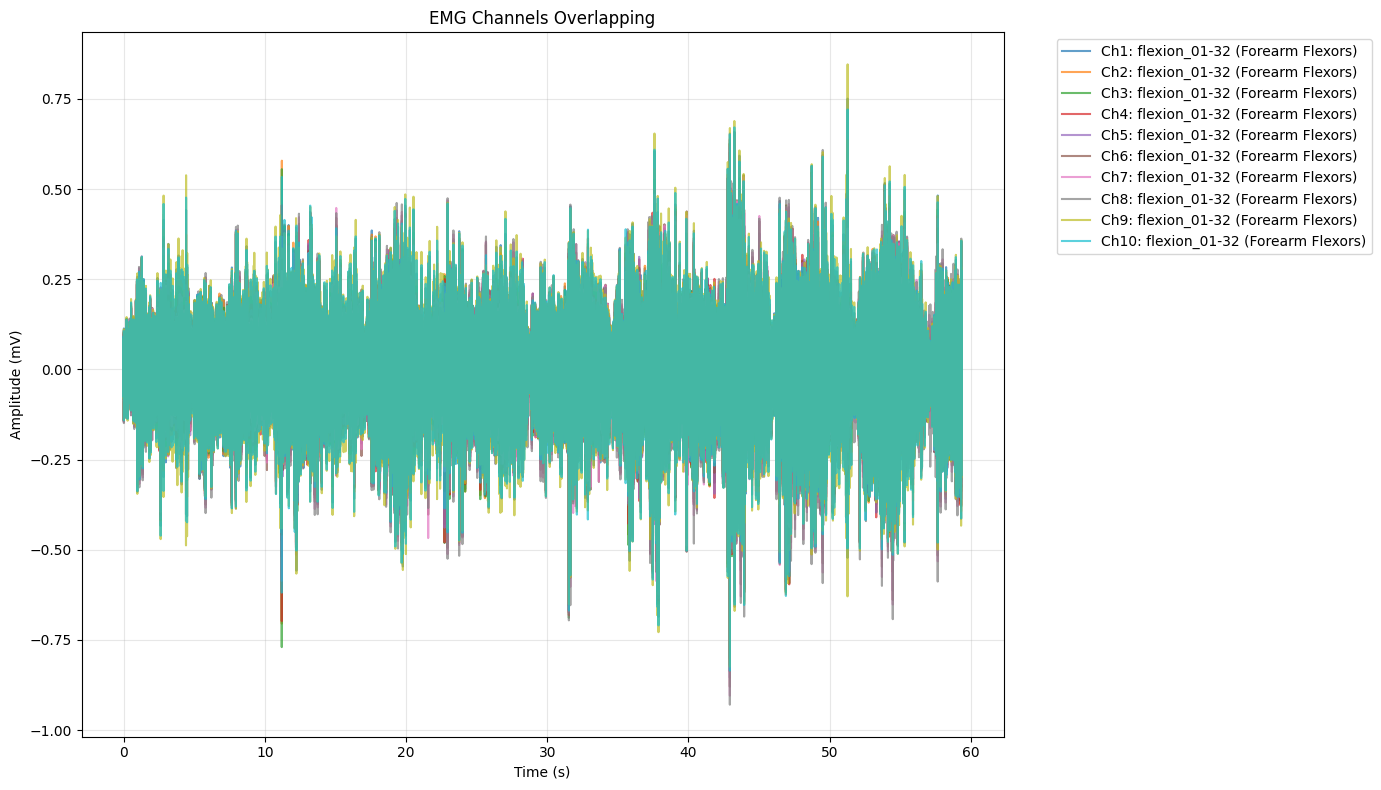

In [5]:
# Plot all EMG channels overlapping on the same plot for direct comparison
print("EMG Channels Overlapping (All Muscle Channels on Same Plot - Cometa System):")
plot_emg_channels(time, emg_channels, show_labels=True, acquisition='cometa', overlapping=True, figsize=(14, 8))

print("\nEMG Channels Overlapping (First 10 Channels - Sessantaquattro System):")
plot_emg_channels(time_sess, emg_channels_sess.iloc[:, :10], show_labels=True, acquisition='sessantaquattro', overlapping=True, figsize=(14, 8))

## Comparison of Different Hand Movement Tasks

Now let's compare EMG patterns between different tasks. We'll look at hand opening (HO) vs hand closing (HC) - these are antagonistic movements that should show different muscle activation patterns.

In [6]:
# Load EMG data for hand opening (HO) and hand closing (HC) tasks
path_ho = os.path.join(os.getcwd(), 'sub-01', 'emg', 'sub-01_task-HO_acq-cometa_emg.csv')
data_ho = pd.read_csv(path_ho, header=None)
time_ho = data_ho.iloc[:, 0]
emg_ho = data_ho.iloc[:, 1:]

path_hc = os.path.join(os.getcwd(), 'sub-01', 'emg', 'sub-01_task-HC_acq-cometa_emg.csv')
data_hc = pd.read_csv(path_hc, header=None)
time_hc = data_hc.iloc[:, 0]
emg_hc = data_hc.iloc[:, 1:]

print(f"Hand Opening (HO) - Data shape: {data_ho.shape}, Duration: {time_ho.max():.2f}s")
print(f"Hand Closing (HC) - Data shape: {data_hc.shape}, Duration: {time_hc.max():.2f}s")

Hand Opening (HO) - Data shape: (104341, 11), Duration: 52.17s
Hand Closing (HC) - Data shape: (123121, 11), Duration: 61.56s


EMG Channels - Hand Opening (HO) Task:


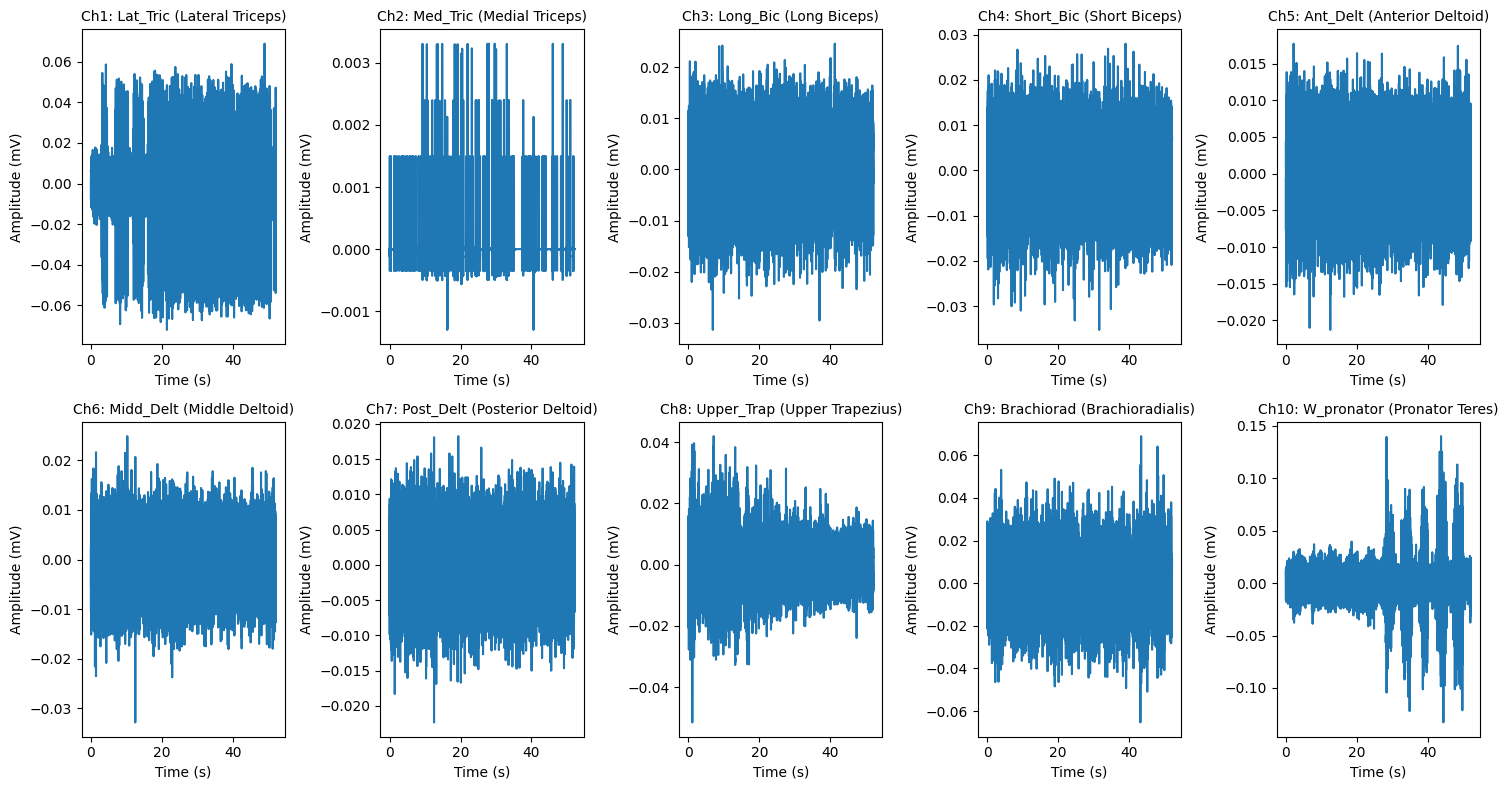


EMG Channels - Hand Closing (HC) Task:


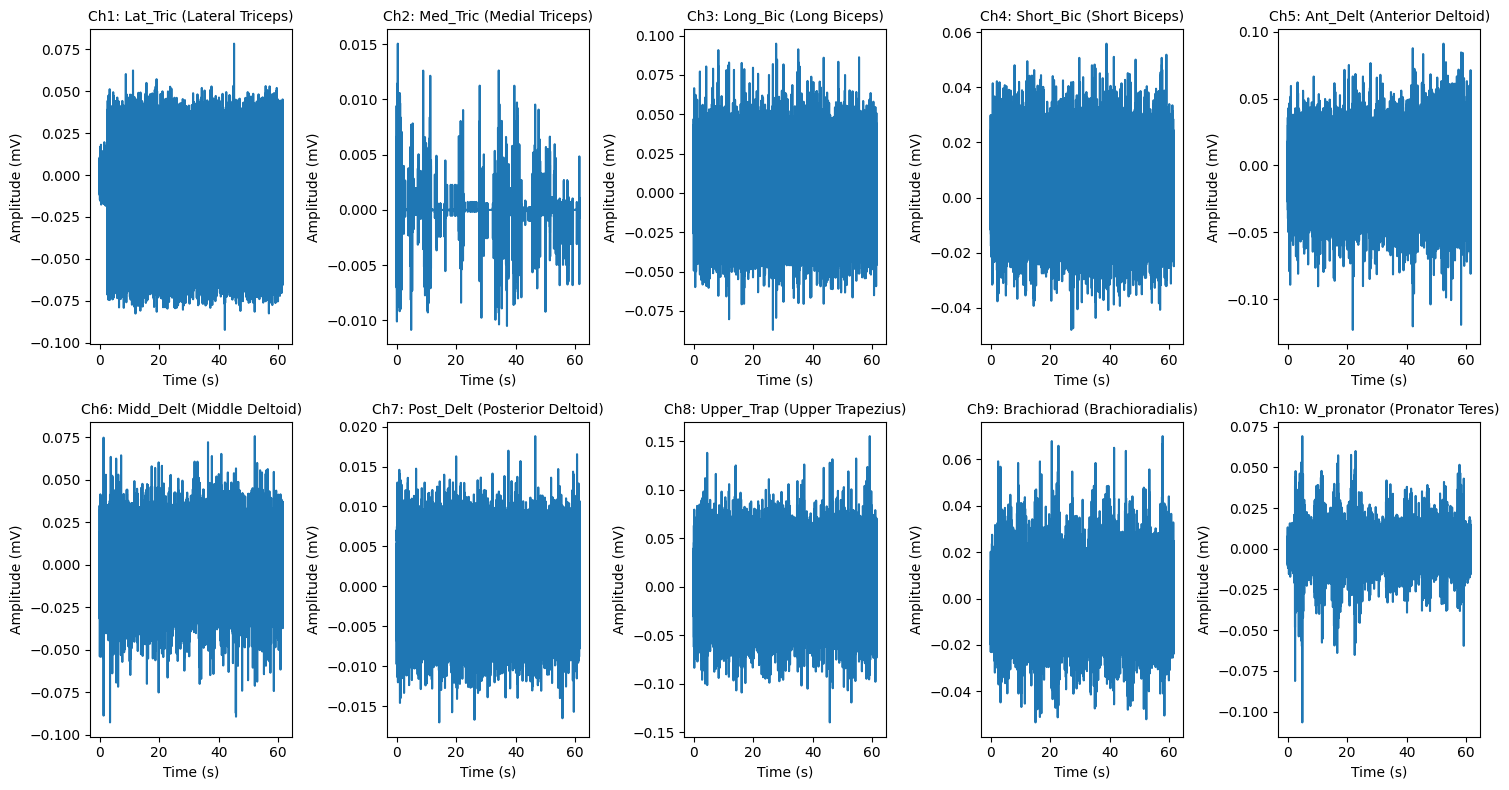

In [7]:
# Compare Hand Opening vs Hand Closing EMG patterns using utility functions
print("EMG Channels - Hand Opening (HO) Task:")
plot_emg_channels(time_ho, emg_ho, show_labels=True, acquisition='cometa', figsize=(15, 8))

print("\nEMG Channels - Hand Closing (HC) Task:")
plot_emg_channels(time_hc, emg_hc, show_labels=True, acquisition='cometa', figsize=(15, 8))

## Basic Signal Statistics

Let's examine some basic statistics of the EMG signals to understand their characteristics.

### EMG Signal Characteristics
EMG signals are electrical manifestations of muscle activity and have specific properties:
- **Raw signals** often have DC offsets from amplification
- **Mean amplitude** is less informative due to baseline shifts
- **RMS (Root Mean Square)** represents signal power/energy
- **MAV (Mean Absolute Value)** indicates average signal magnitude
- **Peak amplitude** shows maximum signal excursions
- **Variance** indicates signal variability over time

These metrics help quantify muscle activation levels and patterns.

In [8]:
# Calculate basic statistics for EMG signals
print("=== EMG Signal Statistics ===\n")
print("Note: Raw mean amplitude is less meaningful for EMG signals due to DC offsets.")
print("More relevant metrics are RMS (signal power), MAV (mean absolute value), and peak amplitude.\n")

datasets = {
    'Cyl (Cometa)': emg_channels,
    'Cyl (Sessantaquattro)': emg_channels_sess,
    'Hand Opening (HO)': emg_ho,
    'Hand Closing (HC)': emg_hc
}

for name, data in datasets.items():
    print(f"{name}:")
    # Mean Absolute Value (MAV) - more meaningful than raw mean for EMG
    mav = data.abs().mean()
    print(f"  Mean Absolute Value (MAV): {mav.round(4).tolist()}")
    print(f"  RMS (signal power): {np.sqrt((data**2).mean()).round(4).tolist()}")
    print(f"  Peak amplitude: {data.abs().max().round(4).tolist()}")
    print(f"  Signal variance: {data.var().round(4).tolist()}")
    print()

# Overall statistics
print("=== Overall Dataset Info ===")
print(f"Sampling frequency: 2000 Hz")
print(f"All datasets have 10 EMG channels")
print(f"Typical recording duration: ~30-60 seconds per task")
print(f"EMG signals: Raw signals with DC offset; RMS/MAV better than raw mean for amplitude")
print(f"Signal range: Typically 0-5 mV RMS for voluntary contractions")

=== EMG Signal Statistics ===

Note: Raw mean amplitude is less meaningful for EMG signals due to DC offsets.
More relevant metrics are RMS (signal power), MAV (mean absolute value), and peak amplitude.

Cyl (Cometa):
  Mean Absolute Value (MAV): [0.013, 0.0025, 0.0066, 0.0057, 0.0562, 0.0322, 0.0057, 0.0217, 0.0112, 0.0061]
  RMS (signal power): [0.0205, 0.0033, 0.0096, 0.0085, 0.0765, 0.0429, 0.0074, 0.0316, 0.015, 0.0087]
  Peak amplitude: [0.1957, 0.0557, 0.1024, 0.1351, 1.1021, 0.3361, 0.0506, 0.2797, 0.1179, 0.1429]
  Signal variance: [0.0004, 0.0, 0.0001, 0.0001, 0.0059, 0.0018, 0.0001, 0.001, 0.0002, 0.0001]

Cyl (Sessantaquattro):
  Mean Absolute Value (MAV): [0.0716, 0.0689, 0.0674, 0.0663, 0.0657, 0.0653, 0.0654, 0.0652, 0.0763, 0.0738, 0.0715, 0.0696, 0.0693, 0.0689, 0.0683, 0.0672, 0.0799, 0.0773, 0.0744, 0.0732, 0.073, 0.0724, 0.0711, 0.0688, 0.0818, 0.0803, 0.0776, 0.0763, 0.0761, 0.0747, 0.0732, 0.0705, 0.1139, 0.1182, 0.1073, 0.0894, 0.0848, 0.0815, 0.082, 0.0832, 0.11

## Summary

This notebook has introduced the EMG data from Subject 1 in the ReachGrasp dataset:

### Key Findings:
1. **Acquisition Systems**: Two different EMG systems are used:
   - Cometa: 10 channels, Wave Plus system
   - Sessantaquattro: 64 channels, higher resolution system

2. **Task Variety**: Subject 1 performed 16 different hand movement tasks, from simple opening/closing to complex object manipulation

3. **Signal Characteristics**: EMG signals show clear differences between antagonistic movements (opening vs closing) and different tasks

4. **Data Quality**: High sampling rate (2000 Hz) provides detailed temporal resolution for movement analysis

### Next Steps:
- Apply filtering and preprocessing (bandpass 20-500Hz for EMG)
- Extract features (RMS, wavelet transforms)
- Synchronize with motion capture and tactile data
- Compare across subjects
- Apply machine learning for movement classification

The `utils/plotting.py` module provides reusable functions for consistent visualization across analyses.

# 2. Motion Capture Analysis

Motion data provides kinematic information about hand and arm movements through joint angles.

## Motion Acquisition Systems

Subject 1 has motion capture data from two systems:
- **CyberGlove**: Glove-based system measuring finger joint angles
- **Vicon**: Optical motion capture system measuring arm and hand kinematics

Both systems record at 100 Hz sampling frequency.

In [9]:
# Load motion data from Vicon system for Cylindrical grasp task
motion_path = os.path.join(os.getcwd(), 'sub-01', 'motion', 'sub-01_task-Cyl_acq-vicon_motion.csv')
motion_data = pd.read_csv(motion_path, header=None)
motion_time = motion_data.iloc[:, 0]
motion_channels = motion_data.iloc[:, 1:]

print(f"Motion data shape: {motion_data.shape}")
print(f"Time range: {motion_time.min():.3f} to {motion_time.max():.3f} seconds")
print(f"Motion channels: {motion_channels.shape[1]}")
print(f"Sampling frequency: 100 Hz")

Motion data shape: (5936, 32)
Time range: 0.000 to 59.350 seconds
Motion channels: 31
Sampling frequency: 100 Hz


Motion Capture Joint Angles (Vicon System):


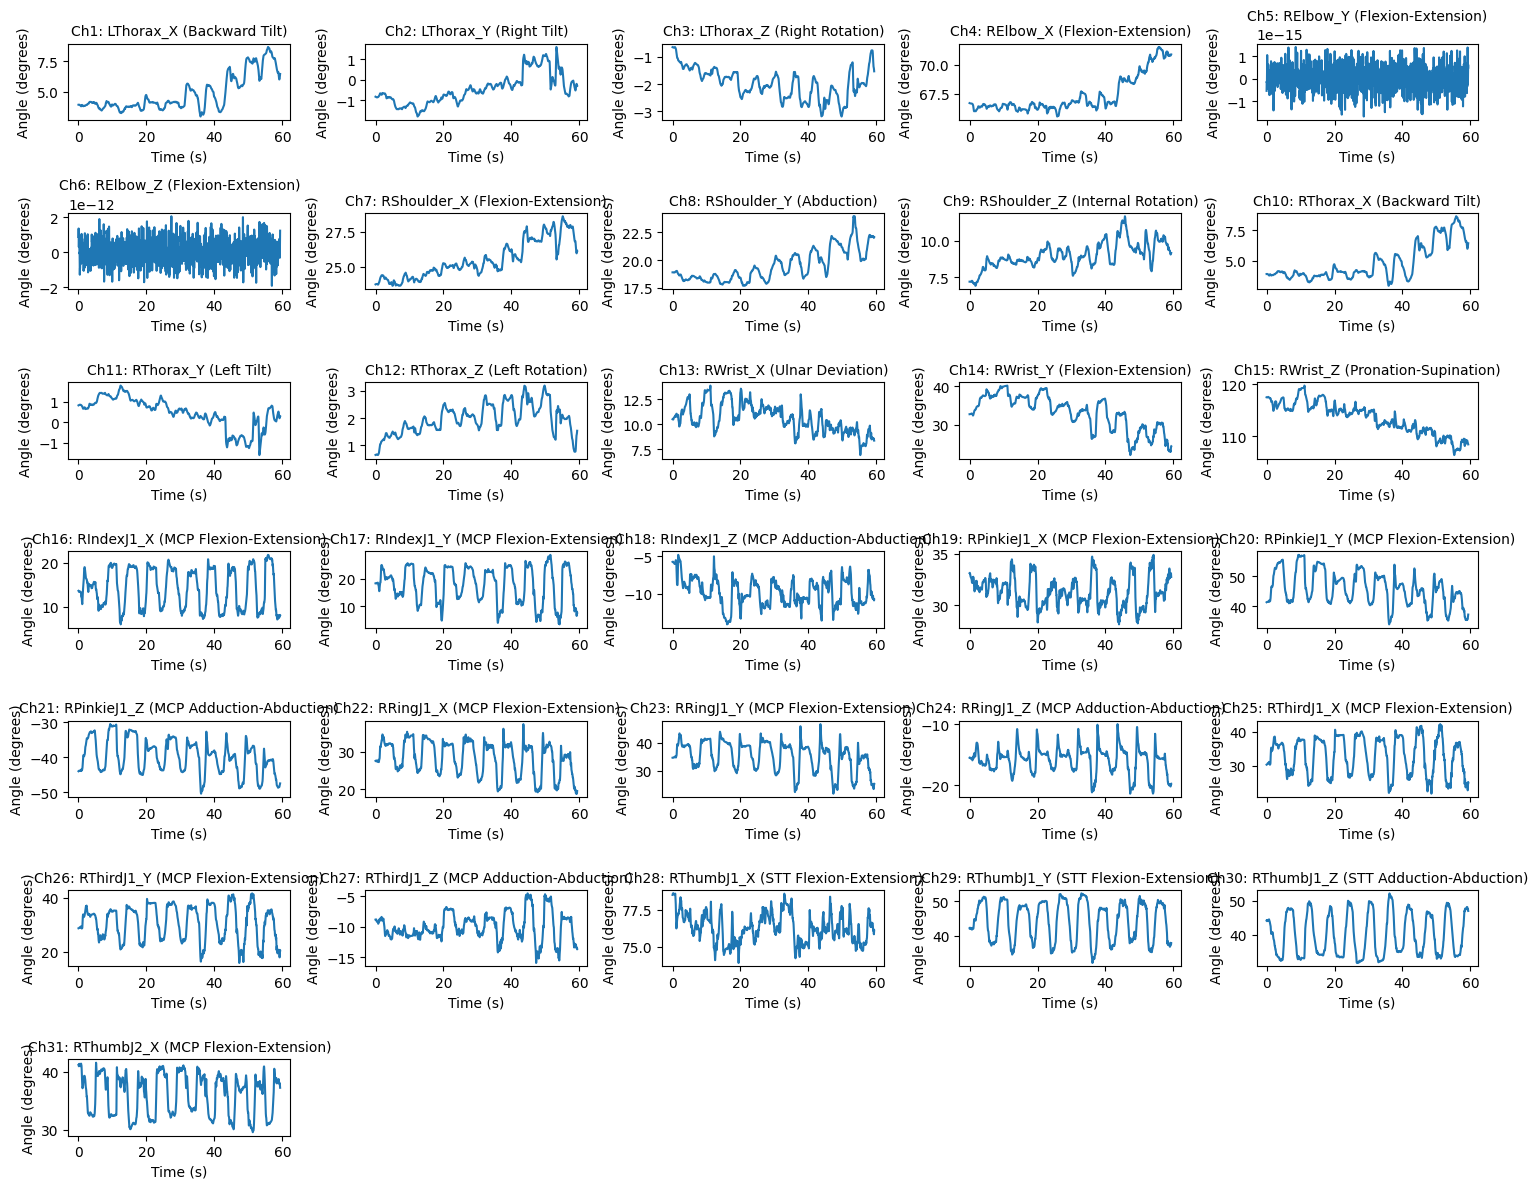

In [10]:
# Plot key joint angles from motion capture using utility function
print("Motion Capture Joint Angles (Vicon System):")
plot_motion_channels(motion_time, motion_channels, show_labels=True, acquisition='vicon', figsize=(15, 12))

Motion Channels Overlapping (All Joint Angles on Same Plot):


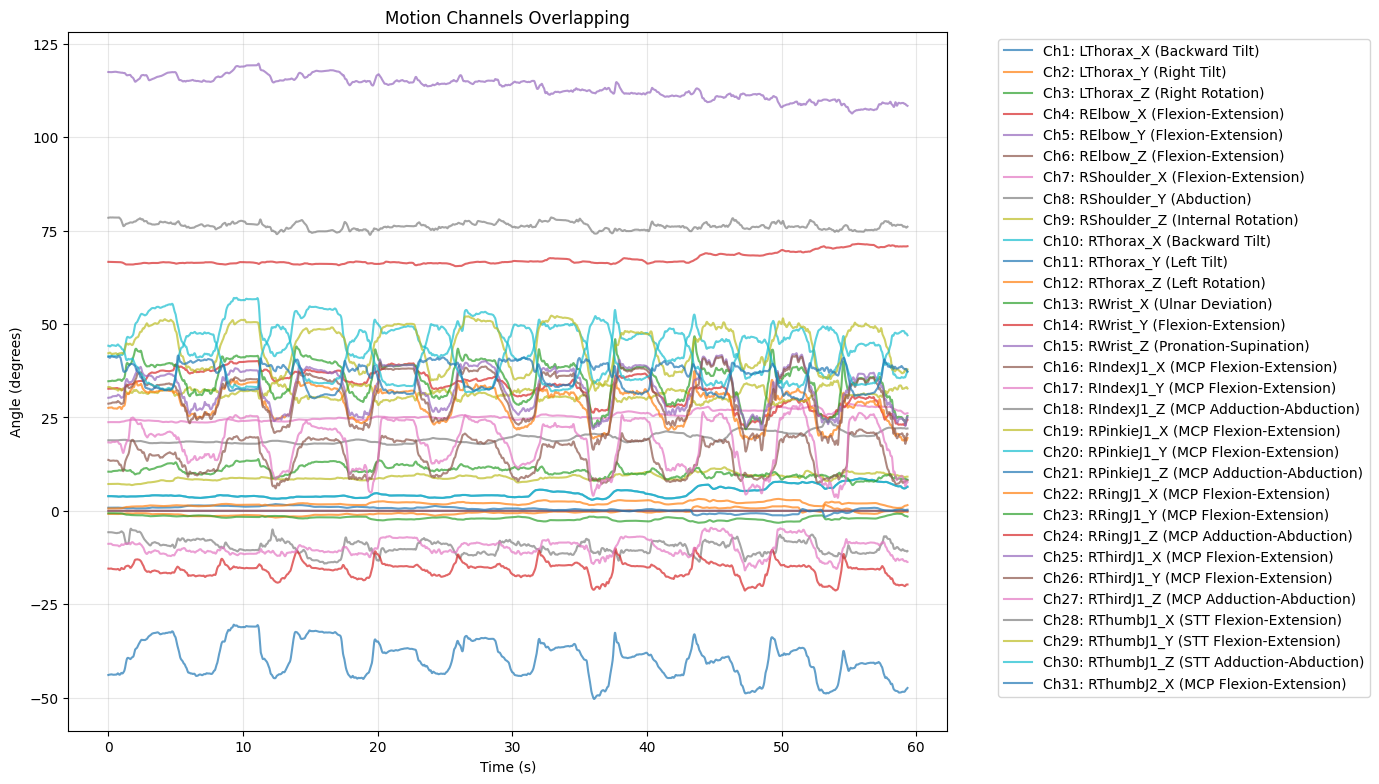

In [11]:
# Plot all motion channels overlapping on the same plot for direct comparison
print("Motion Channels Overlapping (All Joint Angles on Same Plot):")
plot_motion_channels(motion_time, motion_channels, show_labels=True, acquisition='vicon', overlapping=True, figsize=(14, 8))

# 3. Tactile Sensing Analysis

Tactile data provides force measurements from different parts of the hand during grasping and manipulation tasks.

## Tactile Acquisition System

Subject 1 has tactile data from:
- **TactileGlove**: Pressure sensors measuring normal forces across the hand surface

Records at 100 Hz sampling frequency with force measurements in Newtons.

In [12]:
# Load tactile data from TactileGlove system for Cylindrical grasp task
tactile_path = os.path.join(os.getcwd(), 'sub-01', 'tactile', 'sub-01_task-Cyl_acq-tactileglove_tactile.csv')
tactile_data = pd.read_csv(tactile_path, header=None)
tactile_time = tactile_data.iloc[:, 0]
tactile_channels = tactile_data.iloc[:, 1:]

print(f"Tactile data shape: {tactile_data.shape}")
print(f"Time range: {tactile_time.min():.3f} to {tactile_time.max():.3f} seconds")
print(f"Tactile channels: {tactile_channels.shape[1]}")
print(f"Sampling frequency: 100 Hz")

Tactile data shape: (5936, 59)
Time range: 0.000 to 59.350 seconds
Tactile channels: 58
Sampling frequency: 100 Hz


Tactile Force Measurements (TactileGlove System):


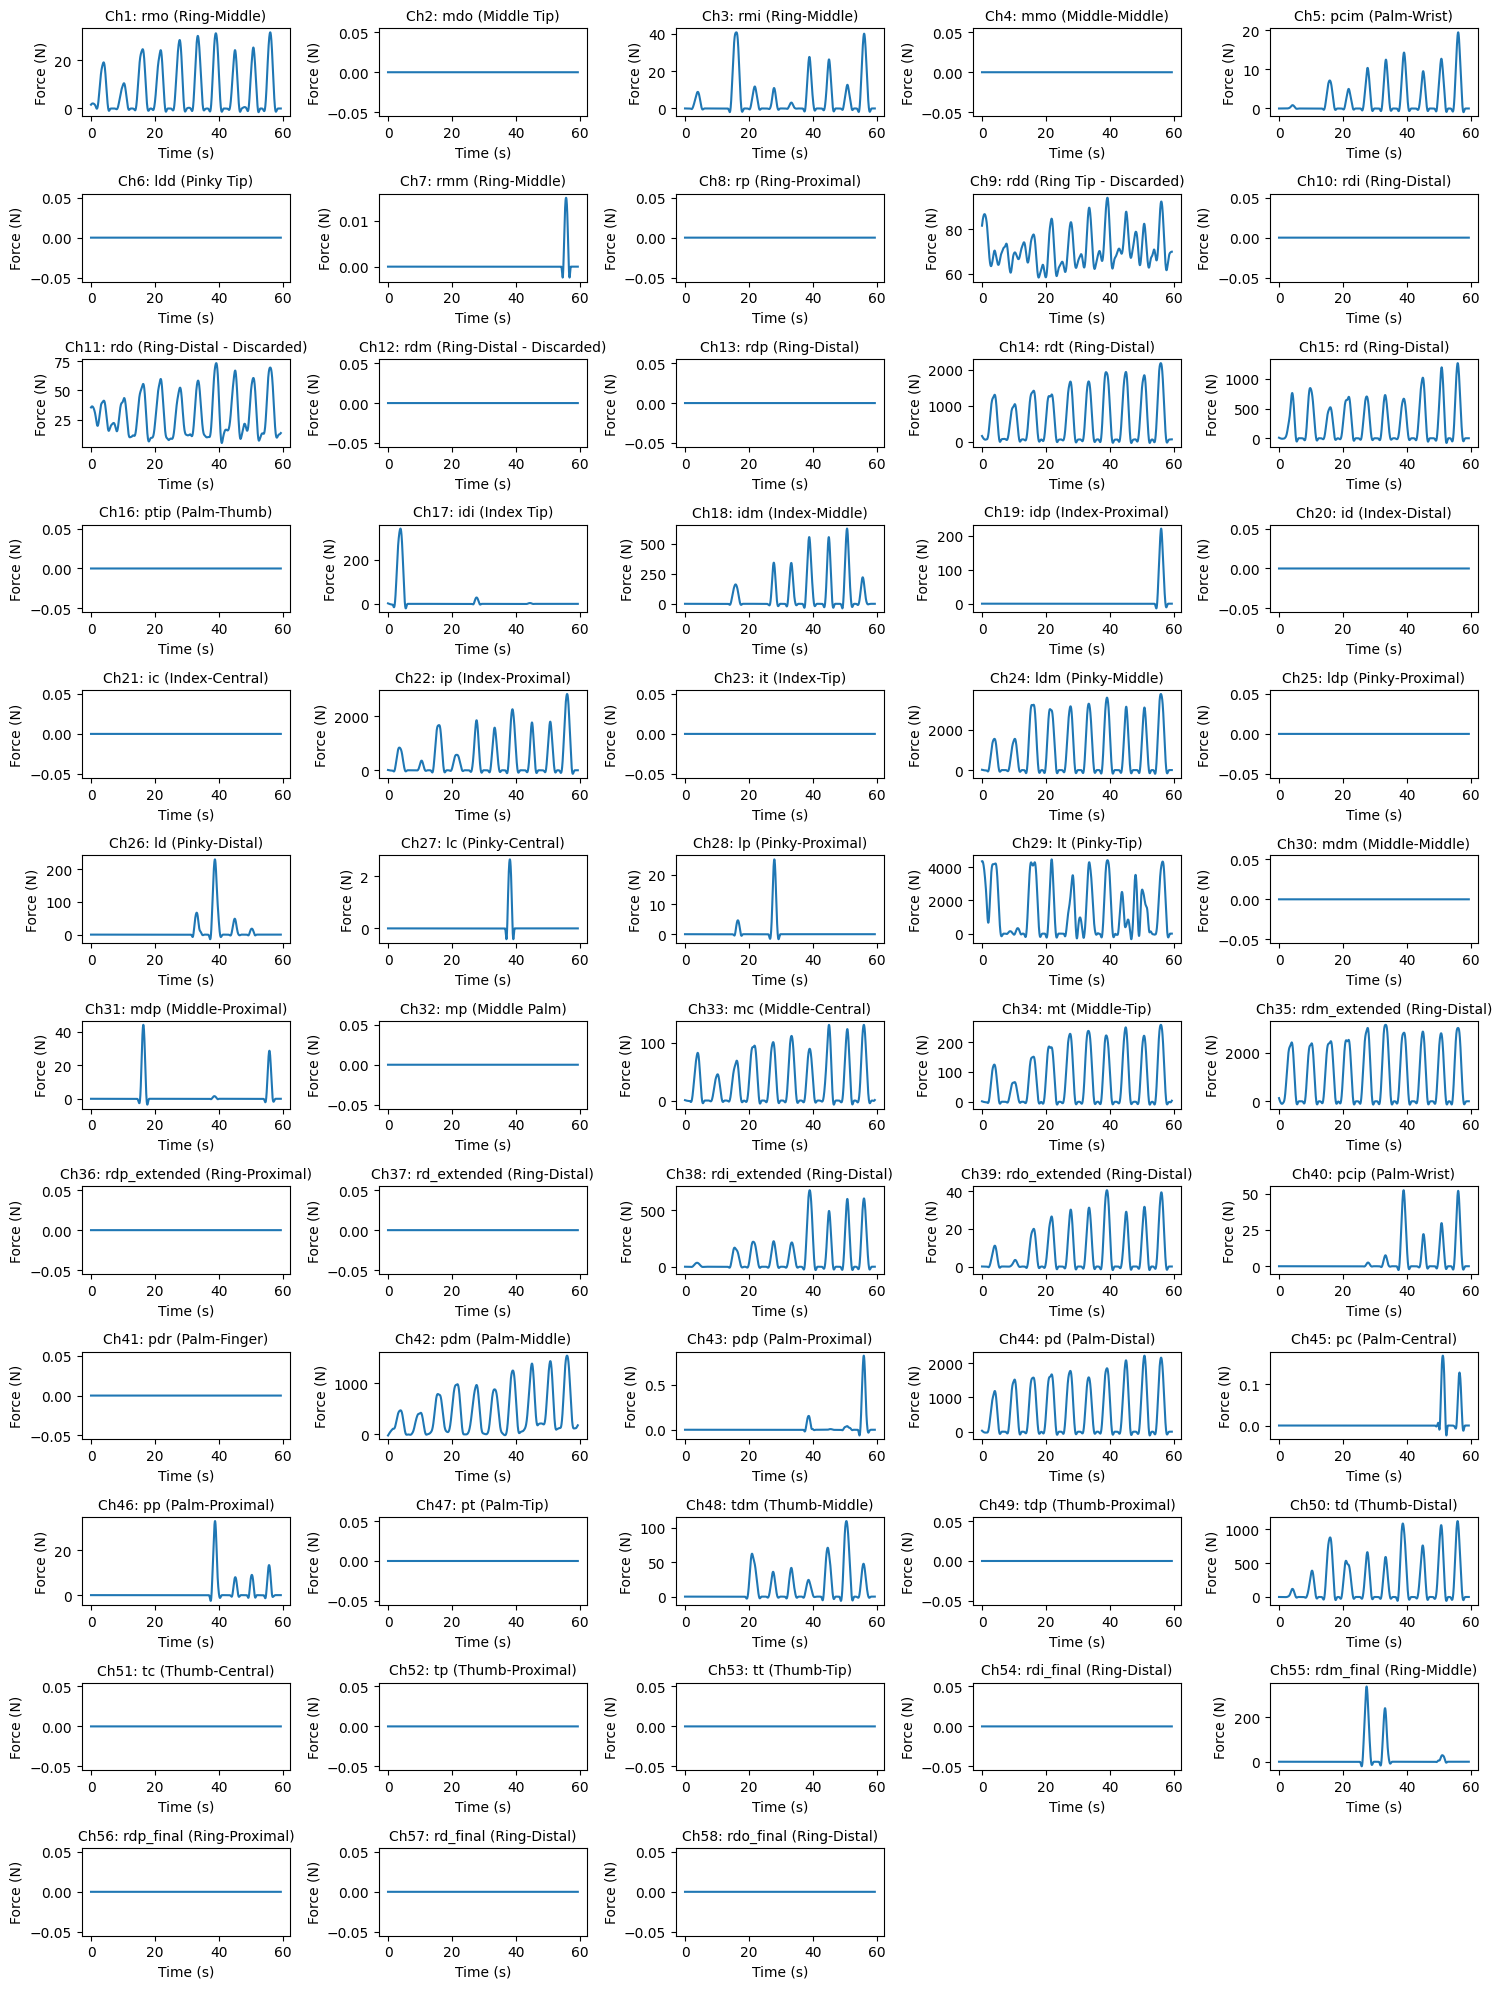

In [13]:
# Plot tactile force measurements using utility function
print("Tactile Force Measurements (TactileGlove System):")
plot_tactile_channels(tactile_time, tactile_channels, show_labels=True, acquisition='tactileglove', figsize=(15, 20))

Tactile Channels Overlapping (All Force Sensors on Same Plot):


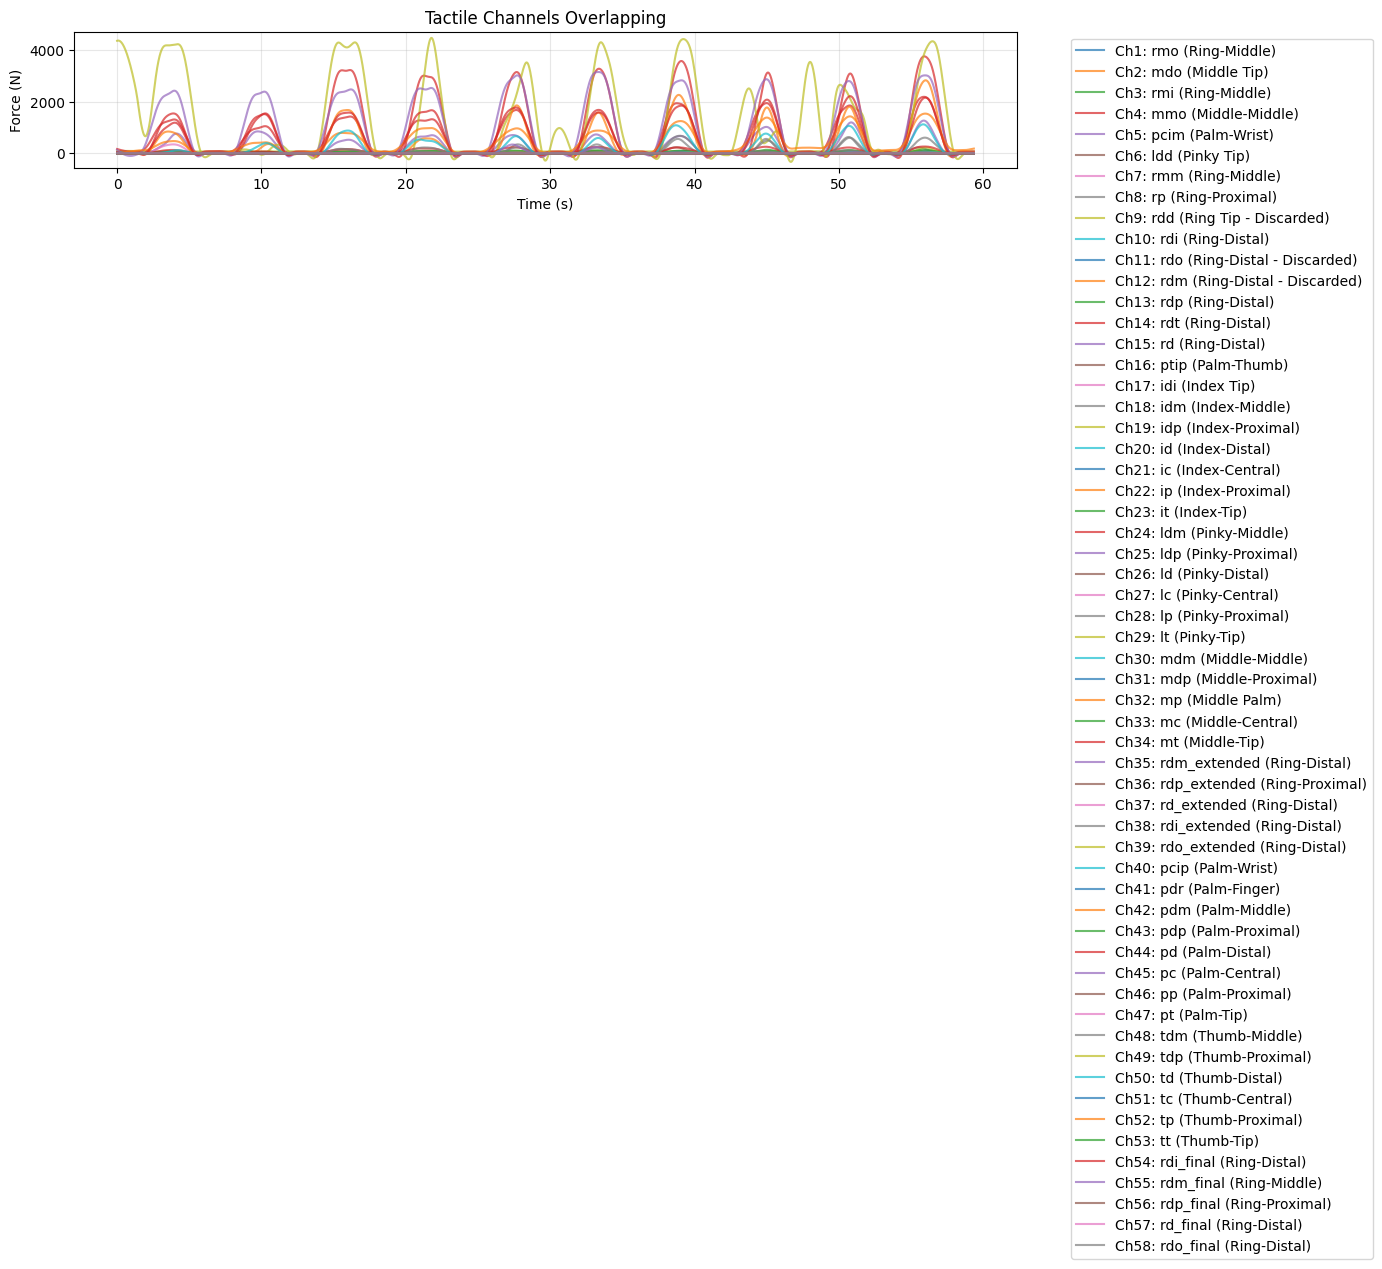

In [14]:
# Plot all tactile channels overlapping on the same plot for direct comparison
print("Tactile Channels Overlapping (All Force Sensors on Same Plot):")
plot_tactile_channels(tactile_time, tactile_channels, show_labels=True, acquisition='tactileglove', overlapping=True, figsize=(14, 8))

# 4. Overlapping Modality Visualization

This section demonstrates advanced visualization techniques that overlay multiple modalities for direct comparison and cross-modal analysis.

Overlapping Modalities (Normalized for Comparison):


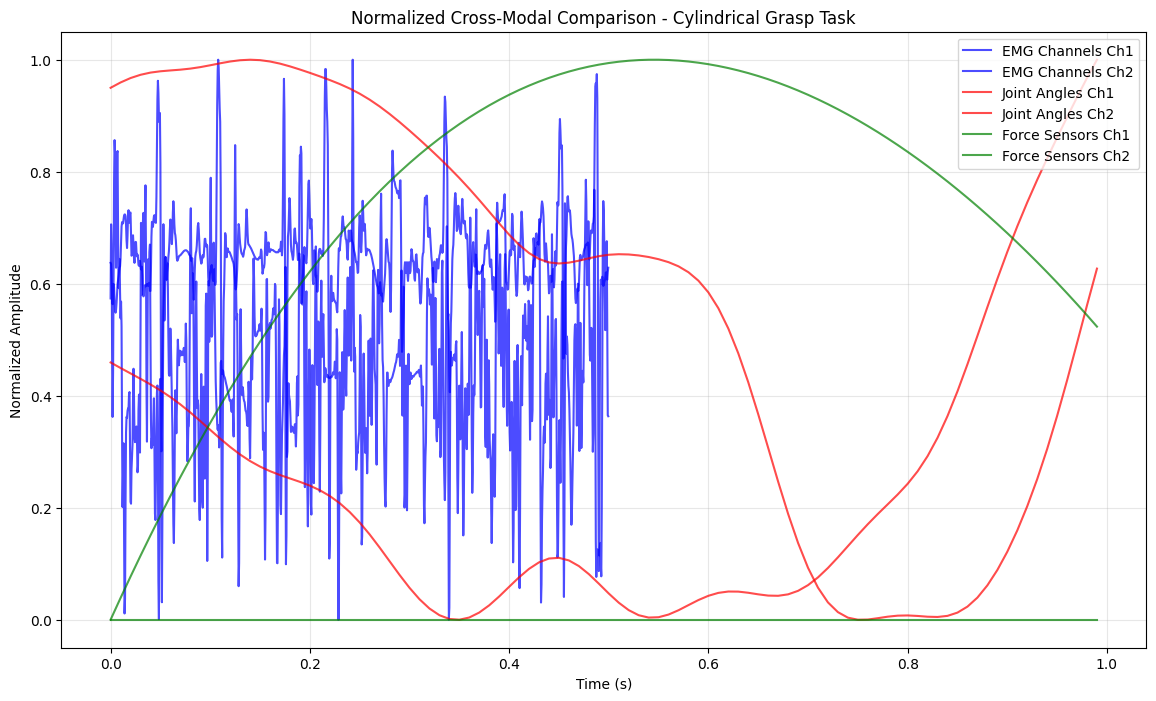

In [15]:
# Overlapping modalities visualization - all on one plot with normalization
print("Overlapping Modalities (Normalized for Comparison):")
data_dict = {
    'emg': (time[:1000], emg_channels.iloc[:1000], [0, 1], 'blue', 'EMG Channels'),
    'motion': (motion_time[:100], motion_channels.iloc[:100], [0, 1], 'red', 'Joint Angles'),
    'tactile': (tactile_time[:100], tactile_channels.iloc[:100], [0, 1], 'green', 'Force Sensors')
}

plot_overlapping_modalities(data_dict, normalize=True, figsize=(14, 8),
                           title="Normalized Cross-Modal Comparison - Cylindrical Grasp Task")

# 5. Cross-Modal Analysis

This section explores relationships between different data modalities during the same task.

## Data Synchronization

Different modalities have different sampling rates:
- EMG: 2000 Hz (high temporal resolution for muscle activity)
- Motion/Tactile: 100 Hz (sufficient for kinematic and force data)

For cross-modal analysis, we need to consider temporal alignment and potential resampling.

Cross-Modal Timeline (Separate Subplots, Aligned Time):


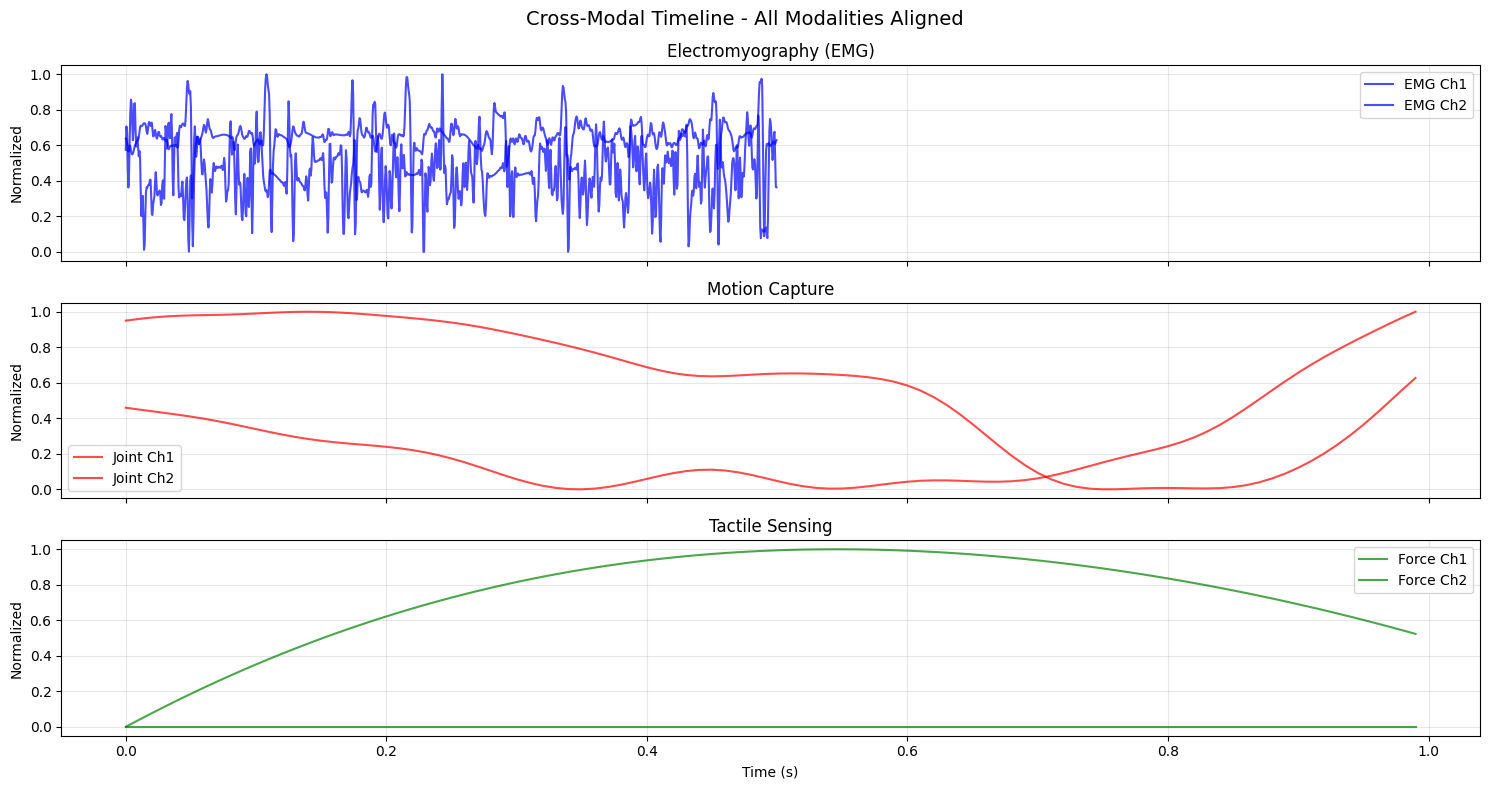

In [16]:
# Cross-modal timeline visualization - separate subplots with aligned time axis
print("Cross-Modal Timeline (Separate Subplots, Aligned Time):")
plot_cross_modal_timeline(
    time[:1000], emg_channels.iloc[:1000],
    motion_time[:100], motion_channels.iloc[:100],
    tactile_time[:100], tactile_channels.iloc[:100],
    emg_channels=[0, 1], motion_channels=[0, 1], tactile_channels=[0, 1],
    normalize=True, figsize=(15, 8),
    title="Cross-Modal Timeline - All Modalities Aligned"
)

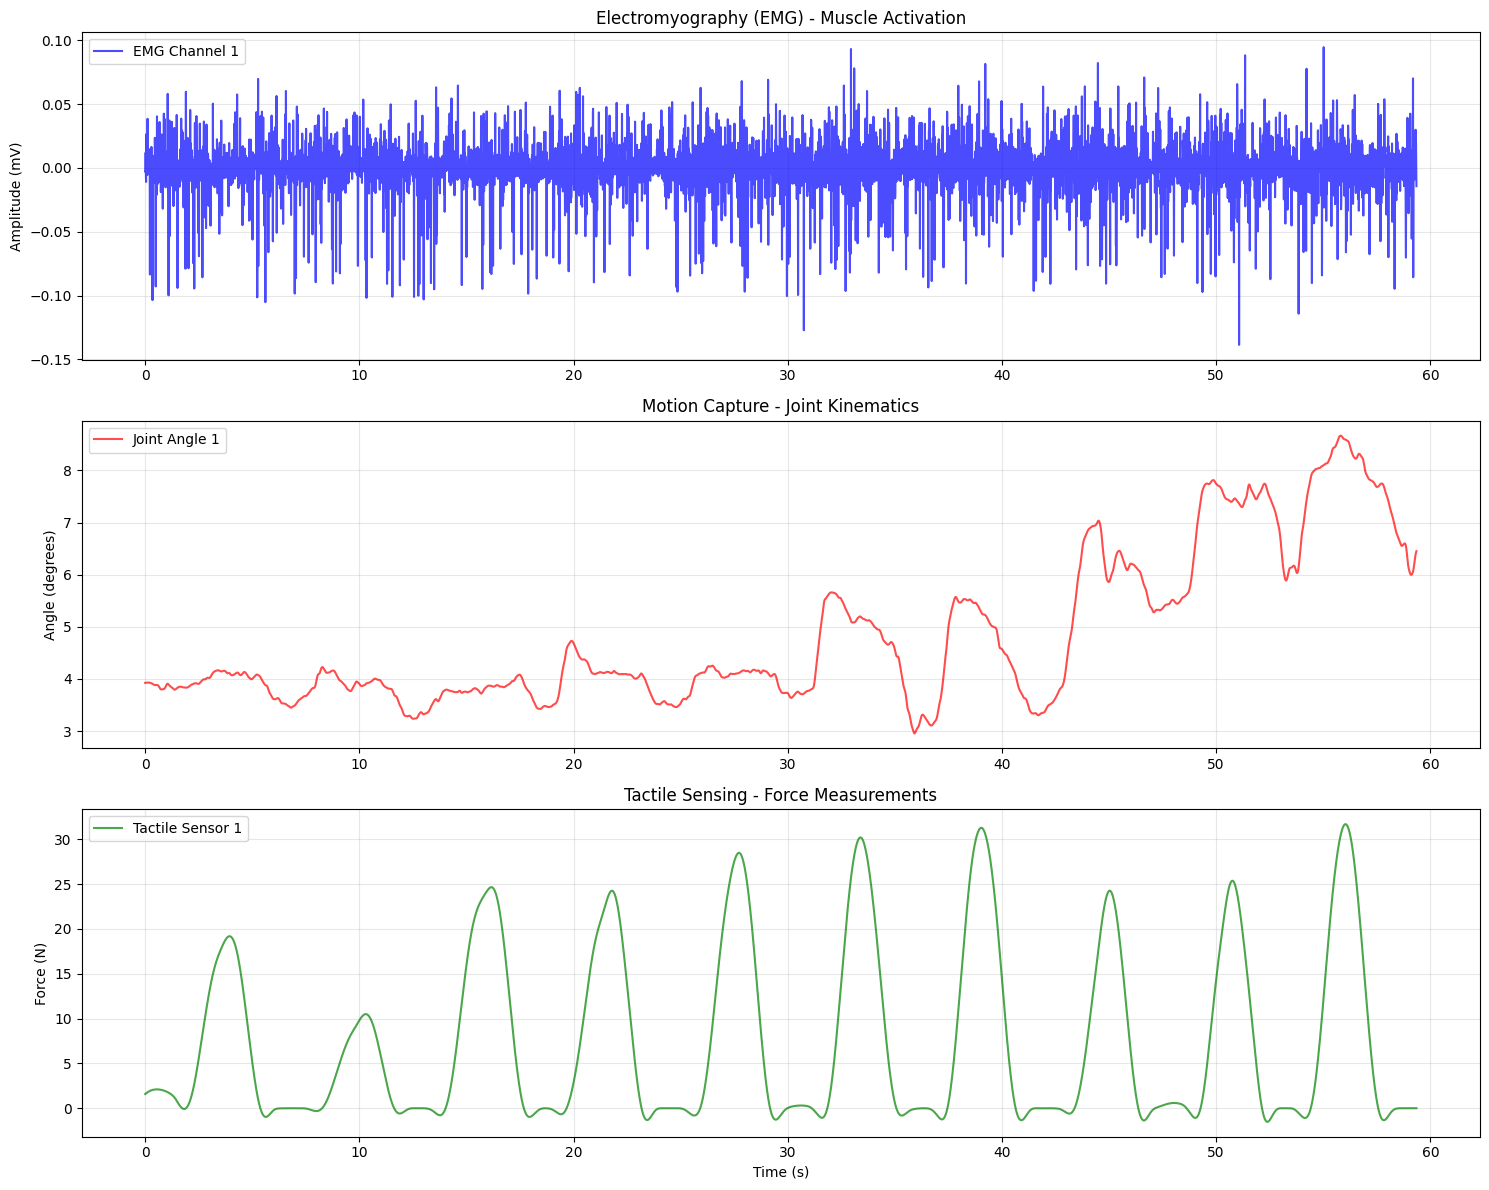

Cross-modal temporal alignment:
EMG duration: 59.35s (2000 Hz)
Motion duration: 59.35s (100 Hz)
Tactile duration: 59.35s (100 Hz)


In [17]:
# Cross-modal visualization: EMG, Motion, and Tactile data alignment
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# EMG data (first channel, subsampled for visualization)
emg_sample = emg_channels.iloc[::20, 0]  # Subsample to ~100 Hz for comparison
time_emg_sample = time[::20]
axes[0].plot(time_emg_sample, emg_sample, 'b-', alpha=0.7, label='EMG Channel 1')
axes[0].set_title('Electromyography (EMG) - Muscle Activation')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Motion data (first joint angle)
axes[1].plot(motion_time, motion_channels.iloc[:, 0], 'r-', alpha=0.7, label='Joint Angle 1')
axes[1].set_title('Motion Capture - Joint Kinematics')
axes[1].set_ylabel('Angle (degrees)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Tactile data (first sensor)
axes[2].plot(tactile_time, tactile_channels.iloc[:, 0], 'g-', alpha=0.7, label='Tactile Sensor 1')
axes[2].set_title('Tactile Sensing - Force Measurements')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Force (N)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Cross-modal temporal alignment:")
print(f"EMG duration: {time.max():.2f}s (2000 Hz)")
print(f"Motion duration: {motion_time.max():.2f}s (100 Hz)")
print(f"Tactile duration: {tactile_time.max():.2f}s (100 Hz)")

## Summary

This notebook has provided a comprehensive analysis of Subject 1's multimodal data from the ReachGrasp dataset:

### Key Findings:

#### 1. EMG Analysis
- **Acquisition Systems**: Cometa (10 channels) vs Sessantaquattro (64 channels) show different resolutions
- **Task Differences**: Clear EMG pattern differences between hand opening vs closing
- **Signal Characteristics**: High temporal resolution (2000 Hz) captures rapid muscle activation changes
- **Amplitude Metrics**: RMS and MAV more meaningful than raw mean due to DC offsets in EMG signals

#### 2. Motion Analysis
- **Joint Kinematics**: Detailed joint angle measurements at 100 Hz
- **Movement Trajectories**: Captures both gross arm movements and fine finger motions
- **Coordinate Systems**: Multiple reference frames for comprehensive kinematic analysis

#### 3. Tactile Analysis
- **Force Distribution**: Pressure measurements across different hand regions
- **Grasp Patterns**: Reveals how forces are distributed during object manipulation
- **Contact Dynamics**: Shows temporal evolution of contact forces

#### 4. Cross-Modal Insights
- **Temporal Alignment**: Different sampling rates require careful synchronization
- **Multimodal Integration**: EMG + Motion + Tactile provides complete picture of grasping
- **Research Applications**: Supports studies in motor control, prosthetics, and rehabilitation

### Technical Notes:
- **Data Synchronization**: EMG (2000Hz) vs Motion/Tactile (100Hz) requires resampling for joint analysis
- **Memory Management**: Large datasets benefit from chunked processing
- **Analysis Pipeline**: Raw data → Filtering → Feature extraction → Classification/Modeling

### Next Steps:
- Apply bandpass filtering to EMG (20-500Hz)
- Extract time-frequency features (wavelet transforms, RMS)
- Implement movement classification algorithms
- Extend analysis to all subjects and tasks
- Develop real-time processing pipelines

The `utils/plotting.py` module provides reusable visualization functions for consistent analysis across modalities.